# UCI BNN — Sampler Investigation

Loads **all available samplers** for one `(dataset, split)` and compares them across:
metrics, sparsity, calibration, posterior noise, ESS, and predictive intervals.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from torch import Tensor
from torch.distributions import Normal

plt.rcParams.update({
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "font.size":          11,
})

import os
if Path.cwd().name == "notebooks":
    os.chdir("..")

## 1. Choose (dataset, split)

In [2]:
RESULTS_DIR   = Path("results/uci_bnn_brent_monotone")

DATASET       = "boston"
SPLIT_ID      = 0
LEARNED_NOISE = True   # True -> *_ln.pt only;  False -> fixed-noise only

# Display-name overrides (stem -> label)
LABELS = {
    "zigzag":              "ZigZag",
    "sticky_zigzag":       "Sticky ZigZag",
    "boomerang":           "Boomerang",
    "sticky_boomerang":    "Sticky Boomerang",
    "nuts":                "NUTS",
    "nuts_horseshoe":      "NUTS-HS",
    "zigzag_ln":           "ZigZag (LN)",
    "sticky_zigzag_ln":    "Sticky ZigZag (LN)",
    "boomerang_ln":        "Boomerang (LN)",
    "sticky_boomerang_ln": "Sticky Boomerang (LN)",
    "nuts_ln":             "NUTS (LN)",
    "nuts_horseshoe_ln":    "NUTS-HS (LN)",
}

# Colour palette — one colour per base sampler family
COLORS = {
    "zigzag":              "#00358B",
    "sticky_zigzag":       "#00358B",
    "boomerang":           "#FA5C00",
    "sticky_boomerang":    "#FA5C00",
    "nuts":                "#0CCA38",
    "nuts_horseshoe":      "#0CCA38",
    "zigzag_ln":           "#00358B",
    "sticky_zigzag_ln":    "#00358B",
    "boomerang_ln":        "#FA5C00",
    "sticky_boomerang_ln": "#FA5C00",
    "nuts_ln":             "#0CCA38",
    "nuts_horseshoe_ln":   "#0CCA38",
}

# Linestyle: solid for sticky/HS, dashed for vanilla
LINESTYLES = {
    "zigzag":              "--",
    "sticky_zigzag":       "-",
    "boomerang":           "--",
    "sticky_boomerang":    "-",
    "nuts":                "--",
    "nuts_horseshoe":      "-",
    "zigzag_ln":           "--",
    "sticky_zigzag_ln":    "-",
    "boomerang_ln":        "--",
    "sticky_boomerang_ln": "-",
    "nuts_ln":             "--",
    "nuts_horseshoe_ln":   "-",
}

## 2. Load runs and reconstruct data split

In [3]:
from sazz.scripts.bnns.uci_bnn import (
    load_raw_datasets, make_split, build_target, build_target_learned_noise,
    BNNConfig, BASE_SEED,
)

split_dir = RESULTS_DIR / DATASET / f"split_{SPLIT_ID:02d}"
all_pts   = sorted(split_dir.glob("*.pt"))
print(split_dir)
# Filter to the chosen noise model
pt_files = [p for p in all_pts if p.stem.endswith("_ln") == LEARNED_NOISE]
assert pt_files, (
    f"No {'learned' if LEARNED_NOISE else 'fixed'}-noise .pt files found in {split_dir}.\n"
    f"Available: {[p.stem for p in all_pts]}"
)

noise_label = "learned noise" if LEARNED_NOISE else "fixed noise"
print(f"Noise model : {noise_label}")
print(f"Found {len(pt_files)} run(s) in {split_dir}:")
for p in pt_files:
    print(f"  {p.stem}")

results/uci_bnn_brent_monotone/boston/split_00
Noise model : learned noise
Found 4 run(s) in results/uci_bnn_brent_monotone/boston/split_00:
  nuts_horseshoe_ln
  nuts_ln
  sticky_boomerang_ln
  sticky_zigzag_ln


In [4]:
print("Loading raw dataset for test-set reconstruction...")
raw = load_raw_datasets()
X_all, y_all = raw[DATASET]

data   = make_split(X_all, y_all, seed=BASE_SEED + SPLIT_ID)
X_test = data["X_test"]
y_test = data["y_test"]
y_std  = data["y_std"]
print(f"  X_test: {X_test.shape}   y_std: {y_std:.4f}")

Loading raw dataset for test-set reconstruction...
  X_test: torch.Size([51, 13])   y_std: 9.3072


## 3. Rebuild targets and compute predictions

One `TorchTarget` is built per noise model type (fixed vs learned). The model reconstruction
is identical to `build_target` / `build_target_learned_noise` in `uci_bnn.py`.

In [5]:
target_cache: dict[bool, object] = {}   # keyed by learned_noise bool

def get_target(run: dict, learned: bool):
    if learned not in target_cache:
        cfg = BNNConfig(
            layer_sizes = run["layer_sizes"],
            activation  = run["activation"],
            noise_std   = run["noise_std"],
            learned_noise = learned,
        )
        builder = build_target_learned_noise if learned else build_target
        print(f"  Building {'learned-noise' if learned else 'fixed-noise'} target "
              f"(layer_sizes={run['layer_sizes']}, act={run['activation']})...")
        target_cache[learned] = builder(data, cfg)
        print(f"    D = {target_cache[learned].D}")
    return target_cache[learned]


def predict_all(samples: Tensor, likelihood, X_new: Tensor) -> Tensor:
    return torch.stack([
        likelihood.predict(beta, X_new).squeeze(-1) for beta in samples
    ])  # [S, N]


runs: dict[str, dict] = {}   # stem -> payload

for pt in pt_files:
    stem    = pt.stem
    learned = stem.endswith("_ln")
    run     = torch.load(pt, map_location="cpu", weights_only=False)
    target  = get_target(run, learned)
    samples = run["samples"]   # [S, D]

    likelihood  = target.meta["model"].likelihood
    preds       = predict_all(samples, likelihood, X_test)   # [S, N]
    mean_pred   = preds.mean(0)
    epist_std   = preds.std(0)
    
    if learned:
        noise_samples = samples[:, -1].exp()       # [S]
        noise_std_eff = float(noise_samples.mean())
    else:
        noise_samples = None
        noise_std_eff = run["noise_std"]

    total_std = (epist_std ** 2 + noise_std_eff ** 2).sqrt()

    base_spec = target.meta.get("base_spec", target.meta["spec"])
    weight_samples = samples[:, :base_spec.D]

    runs[stem] = dict(
        run           = run,
        samples       = samples,
        weight_samples= weight_samples,
        base_spec     = base_spec,
        mean_pred     = mean_pred,
        epist_std     = epist_std,
        total_std     = total_std,
        noise_std_eff = noise_std_eff,
        noise_samples = noise_samples,
        learned       = learned,
        label         = LABELS.get(stem, stem),
        color         = COLORS.get(stem, "grey"),
        ls            = LINESTYLES.get(stem, "-"),
    )
    print(f"  [{stem}] done — {samples.shape[0]} samples")

sampler_order = list(runs.keys())

  Building learned-noise target (layer_sizes=[13, 50, 1], act=relu)...
    D = 752
  [nuts_horseshoe_ln] done — 8000 samples
  [nuts_ln] done — 8000 samples
  [sticky_boomerang_ln] done — 8000 samples
  [sticky_zigzag_ln] done — 8000 samples


In [6]:
# MAP prediction from x_ref (Adam estimate) — one evaluation per run to verify x_ref consistency
X_test_f = X_test.float()
print("MAP predictions (x_ref):")
for stem, s in runs.items():
    x_ref = s["run"]["x_ref"]
    if x_ref is None:
        print(f"  {s['label']}: no x_ref stored")
        continue
    x_ref = x_ref.float()
    likelihood = target_cache[s["learned"]].meta["model"].likelihood
    with torch.no_grad():
        pred = likelihood.predict(x_ref, X_test_f).squeeze(-1)
    noise = x_ref[-1].exp().item() if s["learned"] else s["run"]["noise_std"]
    rmse  = float(((pred - y_test) ** 2).mean().sqrt()) * y_std
    print(f"  {s['label']}: RMSE={rmse:.3f}  noise_std={noise:.3f}")

MAP predictions (x_ref):
  NUTS-HS (LN): RMSE=2.414  noise_std=0.154
  NUTS (LN): RMSE=2.291  noise_std=0.139
  Sticky Boomerang (LN): RMSE=2.301  noise_std=0.140
  Sticky ZigZag (LN): RMSE=2.635  noise_std=0.117


In [7]:
for stem, s in runs.items():
    x_ref = s["run"]["x_ref"]
    if x_ref is None:
        continue
    x_ref = x_ref.float()
    ws = s["samples"].float()
    dists = (ws - x_ref).norm(dim=1)
    print(f"{s['label']}: mean dist={dists.mean():.3f}  std={dists.std():.3f}  max={dists.max():.3f}")


NUTS-HS (LN): mean dist=36.719  std=27.365  max=494.242
NUTS (LN): mean dist=12.062  std=0.495  max=14.286
Sticky Boomerang (LN): mean dist=5.128  std=0.413  max=6.242
Sticky ZigZag (LN): mean dist=11.005  std=0.536  max=12.196


In [8]:
target = target_cache[True]  # True = learned noise
si = target.Sigma_inv  # 1-D diagonal vector [D]

print(f"Shape : {si.shape}")
print(f"Min   : {si.min().item():.4g}")
print(f"Max   : {si.max().item():.4g}")
print(f"Ratio : {(si.max() / si.min()).item():.4g}")
print(f"Mean  : {si.mean().item():.4g}")
print(f"Median: {si.median().item():.4g}")

# Distribution of implied std devs (orbit radii per coordinate)
sigma_diag = (1.0 / si).sqrt()
print(f"\nImplied per-coord std (Sigma_sqrt diagonal):")
print(f"  Min   : {sigma_diag.min().item():.4g}")
print(f"  Max   : {sigma_diag.max().item():.4g}")
print(f"  Mean  : {sigma_diag.mean().item():.4g}")
print(f"  Median: {sigma_diag.median().item():.4g}")


Shape : torch.Size([752])
Min   : 1
Max   : 93.24
Ratio : 93.24
Mean  : 18.22
Median: 14.72

Implied per-coord std (Sigma_sqrt diagonal):
  Min   : 0.1036
  Max   : 1
  Mean  : 0.2687
  Median: 0.2607


In [9]:
target = target_cache[True]
model = target.meta["model"]

# Evaluate energy at x_ref
x_ref = target.x_ref
with torch.no_grad():
    e_ref = model.energy(x_ref).item()

# Try a few more Adam steps from x_ref and see if energy drops
beta = x_ref.clone().requires_grad_(True)
opt = torch.optim.Adam([beta], lr=1e-3)
energies = []
for i in range(2000):
    opt.zero_grad()
    loss = model.energy(beta)
    loss.backward()
    opt.step()
    if i % 200 == 0:
        energies.append(loss.item())

print(f"Energy at x_ref      : {e_ref:.4f}")
print(f"Energy after 2k more : {energies[-1]:.4f}")
print(f"Drop                 : {e_ref - energies[-1]:.4f}")
print(energies)


Energy at x_ref      : 21.4386
Energy after 2k more : 11.2925
Drop                 : 10.1461
[21.438594211866985, 18.447332362010627, 16.850528061965917, 14.935882882257715, 13.50058676948504, 12.621337761391658, 12.143809052185247, 11.693844413227339, 11.44528588354251, 11.292478439631964]


## 4. Metrics table

In [10]:
from sazz.utils.metrics import ess_per_coord
import pandas as pd

def compute_rmse(y_true, mean_pred, y_std):
    return float(((mean_pred - y_true) ** 2).mean().sqrt()) * y_std

def compute_nll(y_true, mean_pred, total_std, y_std):
    ll = (-0.5 * ((y_true - mean_pred) / total_std) ** 2
          - total_std.log() - 0.5 * math.log(2 * math.pi)).mean()
    return float(-ll + math.log(y_std))

def compute_crps(y_true, mean_pred, total_std, y_std):
    d = Normal(0.0, 1.0)
    sigma = total_std * y_std
    z = (y_true * y_std - mean_pred * y_std) / sigma
    return float((sigma * (z * (2*d.cdf(z) - 1) + 2*d.log_prob(z).exp()
                           - 1/math.sqrt(math.pi))).mean())

def compute_coverage(y_true, mean_pred, total_std, level=0.9):
    z = Normal(0.0, 1.0).icdf(torch.tensor(0.5 + level / 2))
    return float(((y_true - mean_pred).abs() <= z * total_std).float().mean())

rows = []
for stem, s in runs.items():
    ess   = ess_per_coord(s["weight_samples"])
    elapsed = s["run"]["elapsed_sec"]
    rows.append({
        "Sampler":    s["label"],
        "RMSE":       compute_rmse(y_test, s["mean_pred"], y_std),
        "NLL":        compute_nll(y_test, s["mean_pred"], s["total_std"], y_std),
        "CRPS":       compute_crps(y_test, s["mean_pred"], s["total_std"], y_std),
        "Cov 90%":    compute_coverage(y_test, s["mean_pred"], s["total_std"], 0.90),
        "Cov 95%":    compute_coverage(y_test, s["mean_pred"], s["total_std"], 0.95),
        "ESS min":    float(ess.min()),
        "ESS/s":      float(ess.min()) / elapsed,
        "Time (s)":   elapsed,
    })

metrics_df = pd.DataFrame(rows).set_index("Sampler")

def highlight_coverage(col):
    target = 0.90 if "90" in col.name else 0.95
    best = (col - target).abs().idxmin()
    return ["background-color: #68dc0f" if idx == best else "" for idx in col.index]


In [11]:

metrics_df.style \
    .highlight_min(subset=["RMSE", "NLL", "CRPS"], color="#68dc0f") \
    .highlight_max(subset=["ESS/s"], color="#68dc0f") \
    .apply(highlight_coverage, subset=["Cov 90%", "Cov 95%"]) \
    .format(precision=5)

,RMSE,NLL,CRPS,Cov 90%,Cov 95%,ESS min,ESS/s,Time (s)
Sampler,,,,,,,,
NUTS-HS (LN),2.33047,3.37248,2.84409,1.00000,1.00000,11.84019,0.01135,1043.27366
NUTS (LN),2.31702,3.44380,3.03951,1.00000,1.00000,176.05520,0.23632,744.98484
Sticky Boomerang (LN),2.34546,2.24443,1.28233,0.94118,0.96078,183.84749,0.07098,2590.09283
Sticky ZigZag (LN),2.34458,2.27186,1.29084,0.98039,0.98039,5.31938,0.02167,245.50883


## 5. Sparsity profiles

NUTS-HS (LN): sparsity=0.050, mean active params=713.8 / 751
NUTS (LN): sparsity=0.003, mean active params=748.9 / 751
Sticky Boomerang (LN): sparsity=0.003, mean active params=748.4 / 751
Sticky ZigZag (LN): sparsity=0.270, mean active params=547.9 / 751


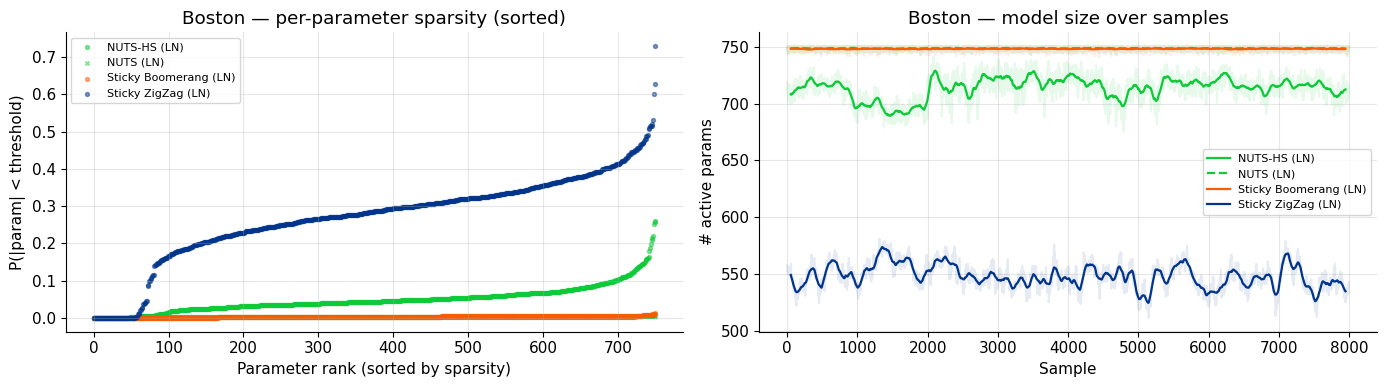

In [12]:
FREEZE_THR = 1e-3
window = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for stem, s in runs.items():
    ws = s["weight_samples"]  # [S, D]

    # --- Sorted sparsity scatter ---
    sparsity = (ws.abs() < FREEZE_THR).float().mean(dim=0).numpy()
    sorted_sparsity = np.sort(sparsity)
    axes[0].scatter(range(len(sorted_sparsity)), sorted_sparsity,
                    alpha=0.5, color=s["color"], label=s["label"], s=8,
                    marker=("o" if s["ls"] == "-" else "x"))

    # --- Model size over samples ---
    model_size = (ws.abs() >= FREEZE_THR).sum(dim=1).float()
    rolling_mean = model_size.unfold(0, window, 1).mean(dim=1)
    axes[1].plot(model_size.numpy(), alpha=0.1, color=s["color"])
    axes[1].plot(range(window // 2, len(rolling_mean) + window // 2),
                 rolling_mean.numpy(), color=s["color"], ls=s["ls"],
                 lw=1.6, label=s["label"])

    print(f"{s['label']}: sparsity={sparsity.mean():.3f}, "
          f"mean active params={model_size.mean():.1f} / {ws.shape[1]}")

axes[0].set_xlabel("Parameter rank (sorted by sparsity)")
axes[0].set_ylabel("P(|param| < threshold)")
axes[0].set_title(f"{DATASET.capitalize()} — per-parameter sparsity (sorted)")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Sample")
axes[1].set_ylabel("# active params")
axes[1].set_title(f"{DATASET.capitalize()} — model size over samples")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Posterior noise

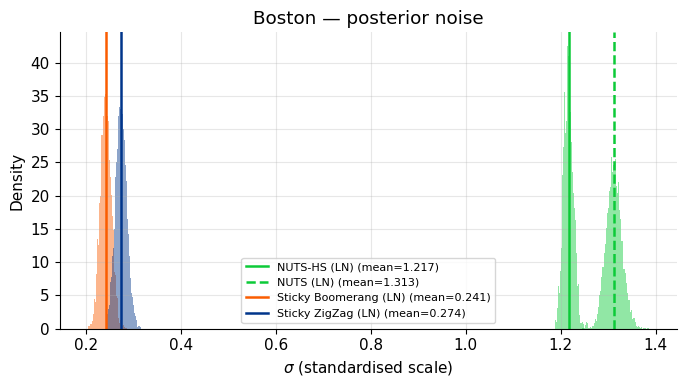

In [13]:
ln_runs = {k: v for k, v in runs.items() if v["learned"]}

if ln_runs:
    fig, ax = plt.subplots(figsize=(7, 4))
    for stem, s in ln_runs.items():
        ns = s["noise_samples"].numpy()
        ax.hist(ns, bins=60, density=True, alpha=0.45,
                color=s["color"], histtype="stepfilled", edgecolor="none")
        ax.axvline(ns.mean(), color=s["color"], lw=1.8, ls=s["ls"],
                   label=f"{s['label']} (mean={ns.mean():.3f})")
    ax.set_xlabel(r"$\sigma$ (standardised scale)")
    ax.set_ylabel("Density")
    ax.set_title(f"{DATASET.capitalize()} — posterior noise")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No learned-noise runs.")